In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA

In [5]:
df = pd.read_csv("BOSCHLTD.csv")   
print(df.head())

          DATE SERIES       OPEN       HIGH        LOW PREV. CLOSE        LTP  \
0  16-Apr-2026     EQ  37,375.00  37,565.00  36,950.00   37,080.00  37,415.00   
1  15-Apr-2026     EQ  37,100.00  37,235.00  36,415.00   36,615.00  37,125.00   
2  13-Apr-2026     EQ  36,665.00  37,385.00  36,420.00   37,330.00  36,615.00   
3  10-Apr-2026     EQ  36,990.00  37,670.00  36,850.00   36,770.00  37,300.00   
4  09-Apr-2026     EQ  36,180.00  37,570.00  35,825.00   35,935.00  36,610.00   

       CLOSE       VWAP      52W H      52W L  VOLUME              VALUE  \
0  37,440.00  37,277.81  41,945.00  26,580.00   31261  1,16,53,41,590.00   
1  37,080.00  36,899.09  41,945.00  26,580.00   92805  3,42,44,20,280.00   
2  36,615.00  36,867.91  41,945.00  26,580.00   57408  2,11,65,13,145.00   
3  37,330.00  37,303.58  41,945.00  25,921.60   83719  3,12,30,18,515.00   
4  36,770.00  36,721.32  41,945.00  25,921.60  262676  9,64,58,08,530.00   

   NO. OF  TRADES  
0           12792  
1           2940

Data Preprocessing

(a) Convert Date Column

In [6]:
df['DATE'] = pd.to_datetime(df['DATE'], format='%d-%b-%Y')

(b) Clean Closing Price

In [7]:
df['CLOSE'] = df['CLOSE'].astype(str).str.replace(',', '').astype(float)

(c) Sort Data

In [8]:
df = df.sort_values('DATE')
df.set_index('DATE', inplace=True)

(d) Handle Missing Values

In [9]:
print(df.isnull().sum())

# Fill or drop (choose one)
df = df.fillna(method='ffill')   # forward fill
# df = df.dropna()

SERIES            0
OPEN              0
HIGH              0
LOW               0
PREV. CLOSE       0
LTP               0
CLOSE             0
VWAP              0
52W H             0
52W L             0
VOLUME            0
VALUE             0
NO. OF  TRADES    0
dtype: int64


C:\Users\Prasad\AppData\Local\Temp\ipykernel_35704\842542320.py:4: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df = df.fillna(method='ffill')   # forward fill


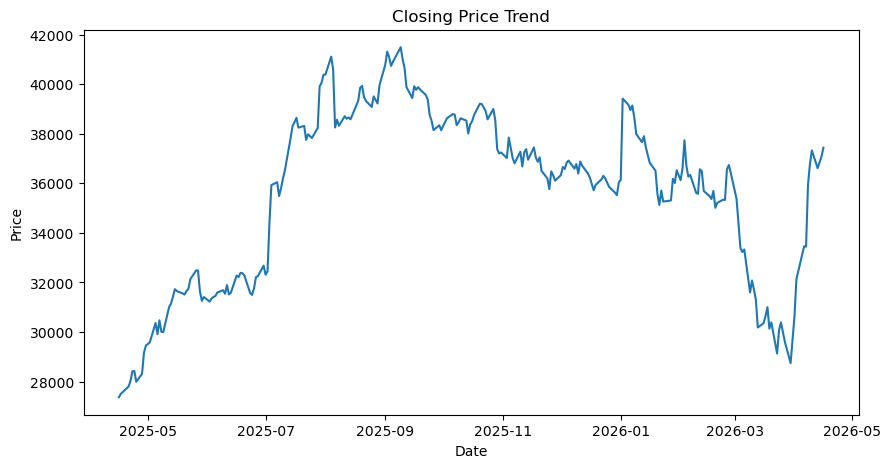

In [10]:
plt.figure(figsize=(10,5))
plt.plot(df['CLOSE'])
plt.title("Closing Price Trend")
plt.xlabel("Date")
plt.ylabel("Price")
plt.show()

5. ADF Test (Stationarity Check)

In [11]:
result = adfuller(df['CLOSE'])

print("ADF Statistic:", result[0])
print("p-value:", result[1])

if result[1] < 0.05:
    print("Series is Stationary")
else:
    print("Series is NOT Stationary")

ADF Statistic: -2.4593550161263713
p-value: 0.1256794054075236
Series is NOT Stationary


6. Differencing (if non-stationary)

In [12]:
df['CLOSE_diff'] = df['CLOSE'].diff()
df = df.dropna()

ADF again

In [13]:
result = adfuller(df['CLOSE_diff'])
print("ADF after differencing:", result[0])
print("p-value:", result[1])

ADF after differencing: -13.890792002185734
p-value: 5.973092512813193e-26


7. ACF and PACF Plots

<Figure size 1000x400 with 0 Axes>

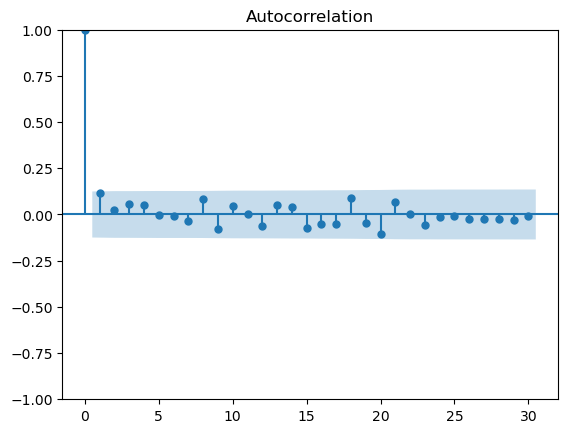

<Figure size 1000x400 with 0 Axes>

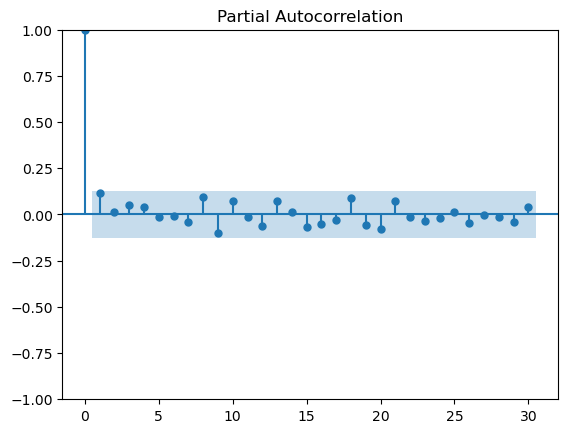

In [14]:
plt.figure(figsize=(10,4))
plot_acf(df['CLOSE_diff'], lags=30)
plt.show()

plt.figure(figsize=(10,4))
plot_pacf(df['CLOSE_diff'], lags=30)
plt.show()

8. Fit ARIMA Model

(Example: ARIMA(1,1,1) — adjust based on ACF/PACF)

In [15]:
model = ARIMA(df['CLOSE'], order=(1,1,1))
model_fit = model.fit()

print(model_fit.summary())

C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:                  CLOSE   No. Observations:                  247
Model:                 ARIMA(1, 1, 1)   Log Likelihood               -1927.696
Date:                Thu, 16 Apr 2026   AIC                           3861.392
Time:                        22:14:33   BIC                           3871.908
Sample:                             0   HQIC                          3865.627
                                - 247                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.6766      0.320      2.114      0.035       0.049       1.304
ma.L1         -0.6065      0.349     -1.738      0.082      -1.290       0.077
sigma2      3.804e+05   1.96e+04     19.405      0.0

9. Model Performance

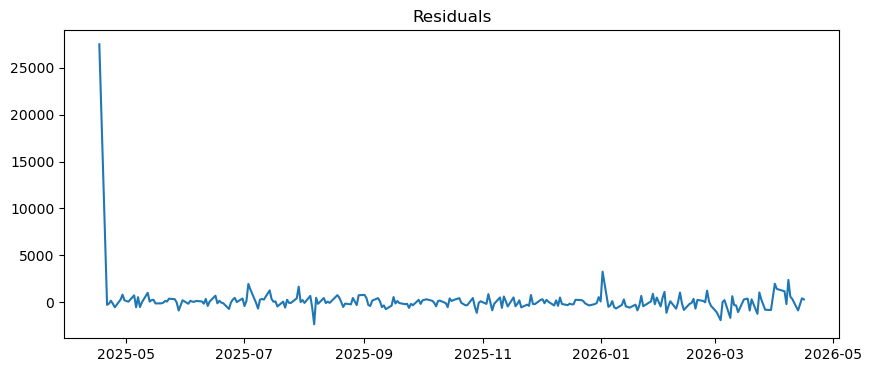

In [16]:
residuals = model_fit.resid

plt.figure(figsize=(10,4))
plt.plot(residuals)
plt.title("Residuals")
plt.show()

10. Forecast Next 30 Days

In [17]:
forecast = model_fit.forecast(steps=30)

C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:836: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:836: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


11. Visualization (Historical + Forecast)

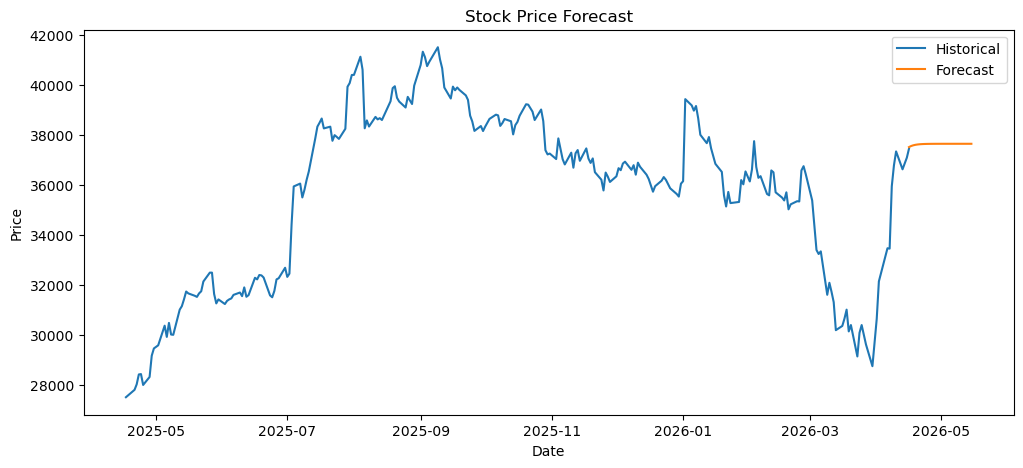

In [18]:
plt.figure(figsize=(12,5))

plt.plot(df.index, df['CLOSE'], label='Historical')
plt.plot(pd.date_range(df.index[-1], periods=30, freq='D'), forecast, label='Forecast')

plt.title("Stock Price Forecast")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.show()

12. Interpretation (Write in Report)

You can include something like:

If forecast shows upward slope → Uptrend expected
If downward → Downtrend
If flat → Stable market
Example Interpretation:

The ARIMA model indicates a moderate upward trend in the next 30 days, suggesting positive market sentiment. However, fluctuations indicate volatility, so predictions should be used cautiously.